In [1]:
import os
import pydicom
import matplotlib.pyplot as plt

### Configuration

In [2]:
# example image path relative to the analysis folder
target_directory = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2", "49_01", "20191106")

def get_first_dicom_file(directory_path):
    """
    Returns the full path of the first non-hidden file in the directory.
    Returns None if directory does not exist or has no valid files.
    """
    if not os.path.exists(directory_path):
        print(f"Error: Directory not found: {os.path.abspath(directory_path)}")
        return None
    
    for filename in os.listdir(directory_path):
        if not filename.startswith("."):
            return os.path.join(directory_path, filename)
            
    return None

### Load example image

Processing file: 1.3.6.1.4.1.14519.5.2.1.9688.9989.206846852338263339128528968856

Metadata Summary

Patient ID:       49_01
Modality:         US
Image Resolution: 768 x 1024
Color Channels:   3


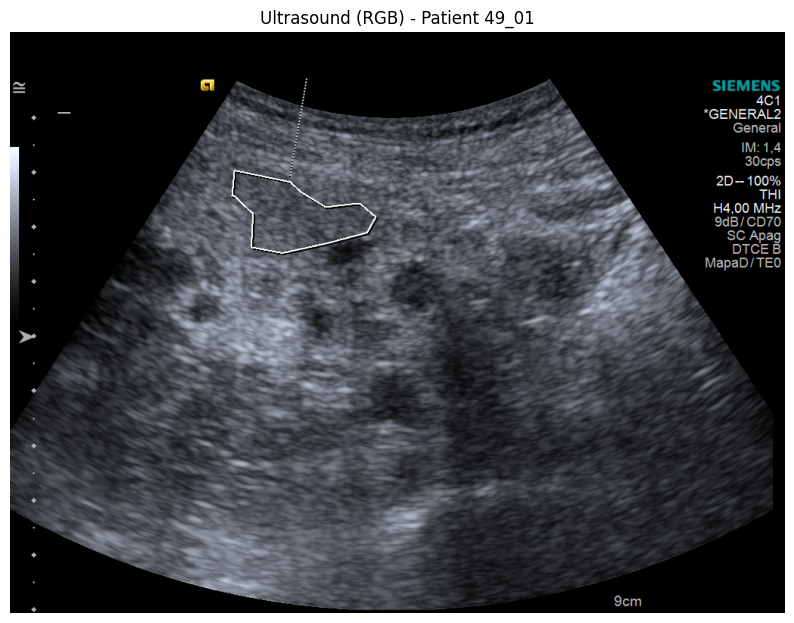


Image visualized successfully.


In [3]:
file_path = get_first_dicom_file(target_directory)

if file_path:
    print(f"Processing file: {os.path.basename(file_path)}\n")
    
    # Load DICOM data
    dataset = pydicom.dcmread(file_path)
    
    # Display Metadata
    print("Metadata Summary\n")
    print(f"Patient ID:       {dataset.PatientID}")
    print(f"Modality:         {dataset.Modality}")
    print(f"Image Resolution: {dataset.Rows} x {dataset.Columns}")
    
    # Determine if image is Color (RGB) or Grayscale
    samples_per_pixel = dataset.get("SamplesPerPixel", 1)
    print(f"Color Channels:   {samples_per_pixel}")

    # Visualization
    image_data = dataset.pixel_array
    plt.figure(figsize=(10, 8))
    
    if samples_per_pixel == 3:
        plt.imshow(image_data)
        plt.title(f"Ultrasound (RGB) - Patient {dataset.PatientID}")
    else:
        plt.imshow(image_data, cmap='gray')
        plt.title(f"Ultrasound (Grayscale) - Patient {dataset.PatientID}")
        
    plt.axis('off')
    plt.show()
    
    print("\nImage visualized successfully.")

else:
    print("No valid DICOM files found in the target folder.")